In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from category_encoders import TargetEncoder

In [35]:
df=pd.read_csv('D:\machine_learning\Algorithms\Linear regression\Student_Performance.csv')

In [36]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [38]:
x=df.drop(columns='Performance Index')
y=df['Performance Index']

In [39]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

<Axes: >

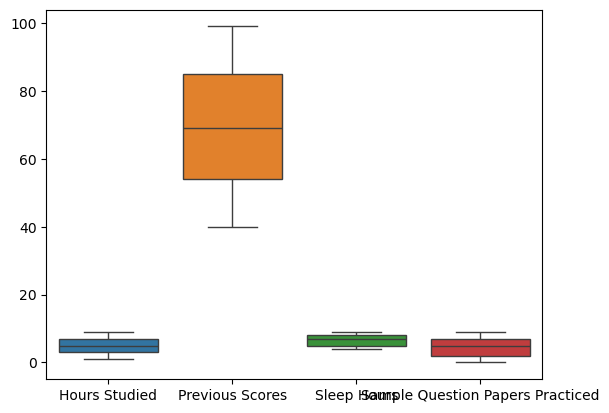

In [40]:
sns.boxplot(x[num_cols])

* Since there are no outliers in the data lets use normalization scaling technique for numerical values

In [41]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [42]:
x_train

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,5,49,No,7,5
1561,2,48,Yes,7,6
1670,2,81,No,7,2
6087,2,46,No,6,1
6669,8,47,No,9,0
...,...,...,...,...,...
5734,8,50,Yes,6,6
5191,4,68,No,9,3
5390,9,48,No,7,6
860,1,47,No,9,0


In [43]:
scaler=MinMaxScaler()
x_train[num_cols]=scaler.fit_transform(x_train[num_cols])
x_train

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,0.500,0.152542,No,0.6,0.555556
1561,0.125,0.135593,Yes,0.6,0.666667
1670,0.125,0.694915,No,0.6,0.222222
6087,0.125,0.101695,No,0.4,0.111111
6669,0.875,0.118644,No,1.0,0.000000
...,...,...,...,...,...
5734,0.875,0.169492,Yes,0.4,0.666667
5191,0.375,0.474576,No,1.0,0.333333
5390,1.000,0.135593,No,0.6,0.666667
860,0.000,0.118644,No,1.0,0.000000


In [44]:
df.corr(numeric_only=True)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


In [45]:
x_train[obj_cols].nunique()

Extracurricular Activities    2
dtype: int64

In [46]:
x_train[obj_cols]

,Extracurricular Activities
9254,No
1561,Yes
1670,No
6087,No
6669,No
...,...
5734,Yes
5191,No
5390,No
860,No


In [47]:
# label_encoder=LabelEncoder()

# up_xtrain=label_encoder.fit_transform(xtrain['Extracurricular Activities'])

# up_xtrain  # This only gives that column and not others dont use like y=this

# xtrain['Extracurricular Activities']=label_encoder.fit_transform(xtrain['Extracurricular Activities'])

# xtrain

In [48]:
onehot_encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)

# xtrain['Extracurricular Activities']=one_hot_encoder.fit_transform(xtrain['Extracurricular Activities'])

# ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead.

# Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead

# After encoding one hot encoder will create 2 columns how can they be equal to one column i.e xtrain['Extracurricular Activities']

In [49]:
values=onehot_encoder.fit_transform(x_train[obj_cols])
values

array([[1., 0.],
       [0., 1.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]], shape=(8000, 2))

In [50]:
cols=onehot_encoder.get_feature_names_out()
cols

array(['Extracurricular Activities_No', 'Extracurricular Activities_Yes'],
      dtype=object)

In [51]:
x_train[cols]=values
x_train # Here the categorical columns still exists hence drop it

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
9254,0.500,0.152542,No,0.6,0.555556,1.0,0.0
1561,0.125,0.135593,Yes,0.6,0.666667,0.0,1.0
1670,0.125,0.694915,No,0.6,0.222222,1.0,0.0
6087,0.125,0.101695,No,0.4,0.111111,1.0,0.0
6669,0.875,0.118644,No,1.0,0.000000,1.0,0.0
...,...,...,...,...,...,...,...
5734,0.875,0.169492,Yes,0.4,0.666667,0.0,1.0
5191,0.375,0.474576,No,1.0,0.333333,1.0,0.0
5390,1.000,0.135593,No,0.6,0.666667,1.0,0.0
860,0.000,0.118644,No,1.0,0.000000,1.0,0.0


In [52]:
x_train.drop(columns='Extracurricular Activities',inplace=True)
x_train

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
9254,0.500,0.152542,0.6,0.555556,1.0,0.0
1561,0.125,0.135593,0.6,0.666667,0.0,1.0
1670,0.125,0.694915,0.6,0.222222,1.0,0.0
6087,0.125,0.101695,0.4,0.111111,1.0,0.0
6669,0.875,0.118644,1.0,0.000000,1.0,0.0
...,...,...,...,...,...,...
5734,0.875,0.169492,0.4,0.666667,0.0,1.0
5191,0.375,0.474576,1.0,0.333333,1.0,0.0
5390,1.000,0.135593,0.6,0.666667,1.0,0.0
860,0.000,0.118644,1.0,0.000000,1.0,0.0


In [53]:
x_test[num_cols]=scaler.transform(x_test[num_cols])
x_test_obj_cols=onehot_encoder.transform(x_test[obj_cols])
x_test_obj_cols

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [1., 0.],
       [1., 0.]], shape=(2000, 2))

In [54]:
x_test[cols]=x_test_obj_cols
x_test  # Here still the Extracurricular Activities are present so need to drop it

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
6252,0.500,0.491525,No,0.8,0.222222,1.0,0.0
4684,0.125,0.101695,Yes,0.0,0.888889,0.0,1.0
1731,0.750,0.271186,Yes,0.6,0.555556,0.0,1.0
4742,0.625,0.033898,Yes,0.8,0.555556,0.0,1.0
4521,0.750,0.220339,No,0.0,0.666667,1.0,0.0
...,...,...,...,...,...,...,...
6412,0.125,0.508475,No,0.6,0.333333,1.0,0.0
8285,0.375,0.661017,No,1.0,0.333333,1.0,0.0
7853,0.125,0.000000,Yes,0.6,0.222222,0.0,1.0
1095,0.250,0.728814,No,0.6,0.555556,1.0,0.0


In [55]:
x_test.drop(columns='Extracurricular Activities',inplace=True)
x_test

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
6252,0.500,0.491525,0.8,0.222222,1.0,0.0
4684,0.125,0.101695,0.0,0.888889,0.0,1.0
1731,0.750,0.271186,0.6,0.555556,0.0,1.0
4742,0.625,0.033898,0.8,0.555556,0.0,1.0
4521,0.750,0.220339,0.0,0.666667,1.0,0.0
...,...,...,...,...,...,...
6412,0.125,0.508475,0.6,0.333333,1.0,0.0
8285,0.375,0.661017,1.0,0.333333,1.0,0.0
7853,0.125,0.000000,0.6,0.222222,0.0,1.0
1095,0.250,0.728814,0.6,0.555556,1.0,0.0


In [56]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
pred_y_train=model.predict(x_train)
error=y_train-pred_y_train
error

9254    1.529357
1561   -0.696651
1670    1.118681
6087    0.382041
6669   -0.988844
          ...   
5734    3.631411
5191   -0.511155
5390   -1.055422
860    -1.021456
7270    1.422884
Name: Performance Index, Length: 8000, dtype: float64

In [58]:
model.score(x_train,y_train)*100

98.86898790682355

In [59]:
model.score(x_test,y_test)*100

98.89832909573146

In [61]:
model.predict([[8,90,8,2,0,1]])

# But the output is not in the scaled range

c:\Users\mural\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([5617.42338146])

In [63]:
new_input=pd.DataFrame([[8,90,8,2]],columns=num_cols)
new_input=scaler.transform(new_input)
final_output=pd.DataFrame([[new_input[0][1],new_input[0][1],new_input[0][2],new_input[0][3],0,1]])
model.predict(final_output) # Correct Way

c:\Users\mural\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([84.60616116])

In [64]:
model.predict([[0.8,0.75,0.8,0.333,1,0]]) 

c:\Users\mural\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([77.25814133])